# Packages

In [4]:
! pip install datasets plotly nbformat statsmodels seaborn matplotlib scipy numpy pandas scikit-learn -q



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.ticker as mtick

from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.stats.proportion import proportion_confint

sns.set(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

# Données

### Première méthode: A partir d'une API

In [6]:
import requests
import pandas as pd

url = "https://datasets-server.huggingface.co/rows"

all_rows = []

for offset in range(0, 1000, 100):
    params = {
        "dataset": "Uris001/credit-risk-eda",
        "config": "default",
        "split": "train",
        "offset": offset,
        "length": 100
    }

    response = requests.get(url, params=params).json()

    if "rows" not in response:
        break

    all_rows.extend([row["row"] for row in response["rows"]])

df = pd.DataFrame(all_rows)
print(df.head())

   Age  Annual Income Home Ownership  Employment Length (Years) Loan Purpose  \
0   21           9600            OWN                        5.0    EDUCATION   
1   25           9600       MORTGAGE                        1.0      MEDICAL   
2   23          65500           RENT                        4.0      MEDICAL   
3   24          54400           RENT                        8.0      MEDICAL   
4   21           9900            OWN                        2.0      VENTURE   

  Loan Grade  Loan Amount  Interest Rate  Default Status  Loan % of Income  \
0          B         1000          11.14               0              0.10   
1          C         5500          12.87               1              0.57   
2          C        35000          15.23               1              0.53   
3          C        35000          14.27               1              0.55   
4          A         2500           7.14               1              0.25   

  Previous Default  Credit History Length (Years) 

### Deuxième méthode

In [7]:
from datasets import load_dataset

ds = load_dataset("Uris001/credit-risk-eda")

data = ds["train"].to_pandas()
print(data.shape)

(31415, 16)


## Affichage de la base de donnée

In [8]:
data.head()

,Age,Annual Income,Home Ownership,Employment Length (Years),Loan Purpose,Loan Grade,Loan Amount,Interest Rate,Default Status,Loan % of Income,Previous Default,Credit History Length (Years),LTI Group,Income Group,Age Group,Interest Rate Group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,No,2,Low,Very Low,18–25,Medium
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,No,3,Very High,Very Low,18–25,High
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,No,2,Very High,High,18–25,Very High
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Yes,4,Very High,Medium,18–25,Very High
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,No,2,High,Very Low,18–25,Very Low


# Statistiques Descriptives

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 31415 entries, 0 to 31414
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            31415 non-null  int64  
 1   Annual Income                  31415 non-null  int64  
 2   Home Ownership                 31415 non-null  str    
 3   Employment Length (Years)      31415 non-null  float64
 4   Loan Purpose                   31415 non-null  str    
 5   Loan Grade                     31415 non-null  str    
 6   Loan Amount                    31415 non-null  int64  
 7   Interest Rate                  31415 non-null  float64
 8   Default Status                 31415 non-null  int64  
 9   Loan % of Income               31415 non-null  float64
 10  Previous Default               31415 non-null  str    
 11  Credit History Length (Years)  31415 non-null  int64  
 12  LTI Group                      31415 non-null  str    
 1

In [11]:
data.describe()

,Age,Annual Income,Employment Length (Years),Loan Amount,Interest Rate,Default Status,Loan % of Income,Credit History Length (Years)
count,31415.000000,3.141500e+04,31415.000000,31415.000000,31415.000000,31415.000000,31415.000000,31415.000000
mean,27.743466,6.646909e+04,4.786567,9659.268661,11.044241,0.215629,0.169582,5.817030
std,6.206875,5.262203e+04,4.037482,6335.486029,3.204214,0.411265,0.106268,4.062565
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.941000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,84.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [12]:
from statistique_descriptive import Statistique_Descriptives
from statistique_descriptive import analyse_categorielle


<span style="color:blue; font-size:36px; font-weight:bold;">
Objectif:
</span>

<span style="font-size:24px;">
L’objectif de cette étude consiste à identifier et à analyser les facteurs associés à une probabilité élevée de défaut de paiement d’un prêt.
</span>

# I. Statistiques descriptives Univariée

### Statistique descriptives sur le statut des clients

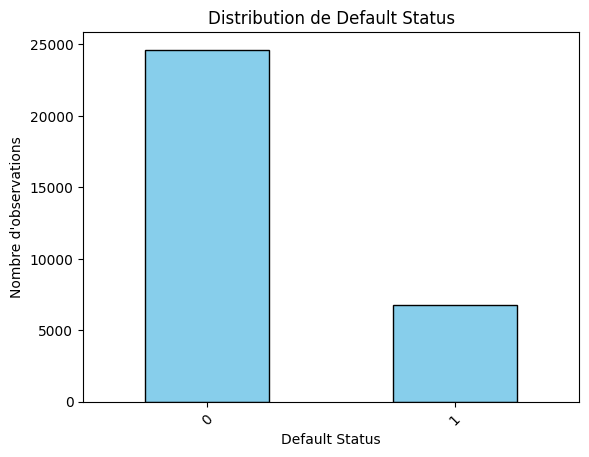

--- Default Status ---
Default Status
0    24641
1     6774
Name: count, dtype: int64




In [ ]:
analyse_categorielle(data, "Default Status")

Il existe environ 21,5 % des clients de la banque qui sont en defaut de paiement de leur pret tandis que 78 % des emprunteurs remboursent leurs prêts. Ce qui montre que l'ensemble du jeu de données est déséquilibré par rapport à cette variable, les cas de non-défaut étant majoritaire.

Cependant, la proportion des cas de défaut est importante, ce qui est suffisant pour permettre une analyse des facteurs influençant le risque de crédit. Mais lors de modélisation, il faudra corriger ce déséquilibre.

### Statistiques descriptives de l'Âge des clients

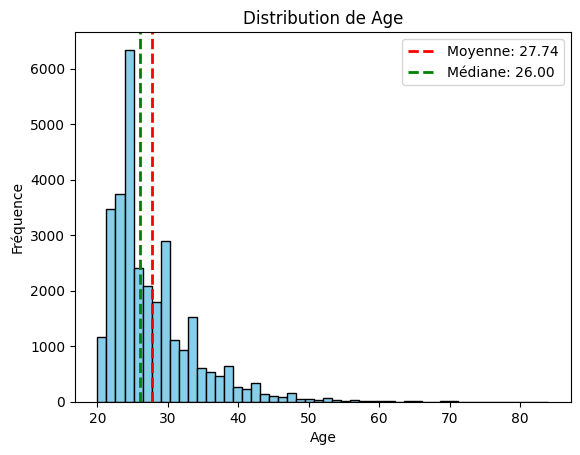

In [ ]:
Statistique_Descriptives(data, "Age")

Un premier contrôle exploratoire montre que l'âge des individus est dans une fourchette assez raisonnable comprise entre 20 et 84 ans. Cela semble très normale vu la situation des individus et l'esperance de vie à la naissance. 

### Analyse du nombre d'année(s) de travail

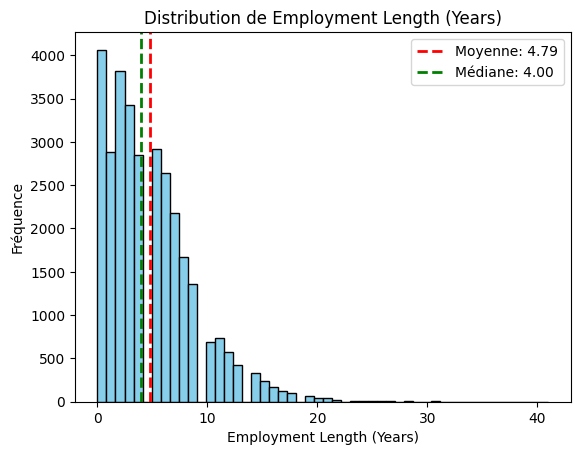

In [ ]:
Statistique_Descriptives(data, "Employment Length (Years)")

Une analyse aussi de nombre d'année d'expérience des individus montre que cela est aussi normale avec la periode allant de 0 à 41 ans d'experience de travail.(<60 ans)

### Analyse des données des taux d'interet

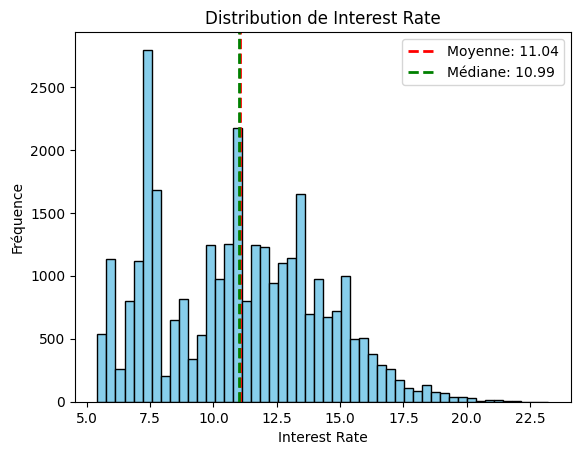

In [ ]:
Statistique_Descriptives(data, "Interest Rate")

Les informations sur les taux d'interet montre que le mode est obtenus pour des valeurs proches de 7,5% ce qui reflète reellement la nature des taux d'interet sur les prèts bancaires. 

### Données sur les montants empruntés

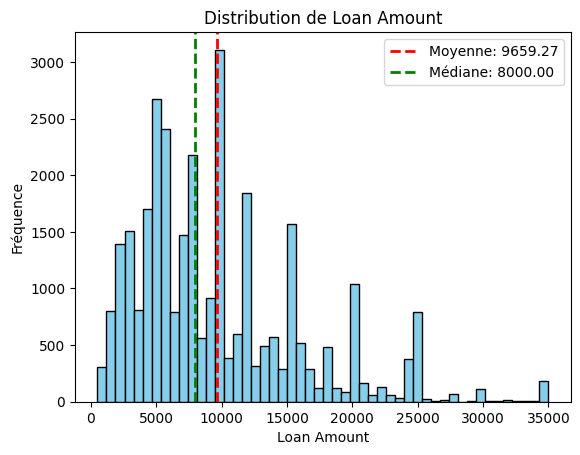

In [ ]:
Statistique_Descriptives(data, "Loan Amount")

Le montant maximal des montants prets est de 35000 euros.

### Analyse des defaut précedement des clients

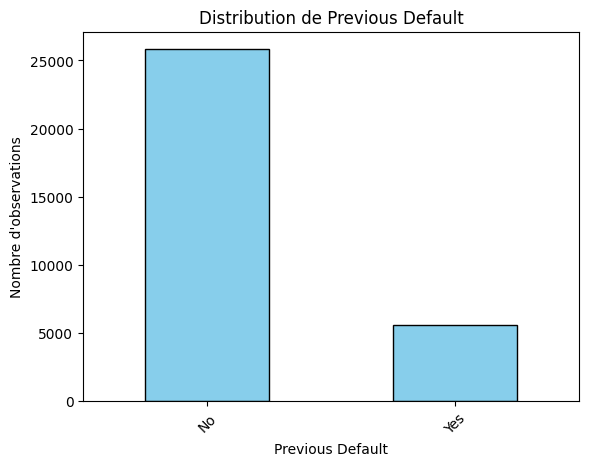

--- Previous Default ---
Previous Default
No     25830
Yes     5585
Name: count, dtype: int64




In [ ]:
analyse_categorielle(data, "Previous Default")

Seulement 17,5% des clients avait fait un defaut sur leur credit precedemment.

### Analyse de Loan-to-Income Group (Montant du pret/Revenu)

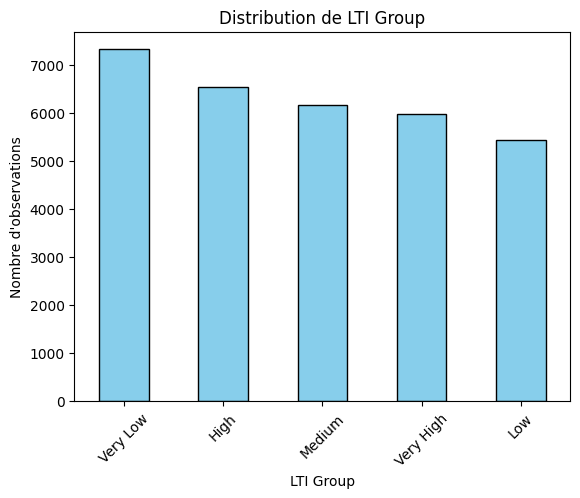

--- LTI Group ---
LTI Group
Very Low     7321
High         6528
Medium       6157
Very High    5981
Low          5428
Name: count, dtype: int64




In [ ]:
analyse_categorielle(data, "LTI Group")

### Loan Grade

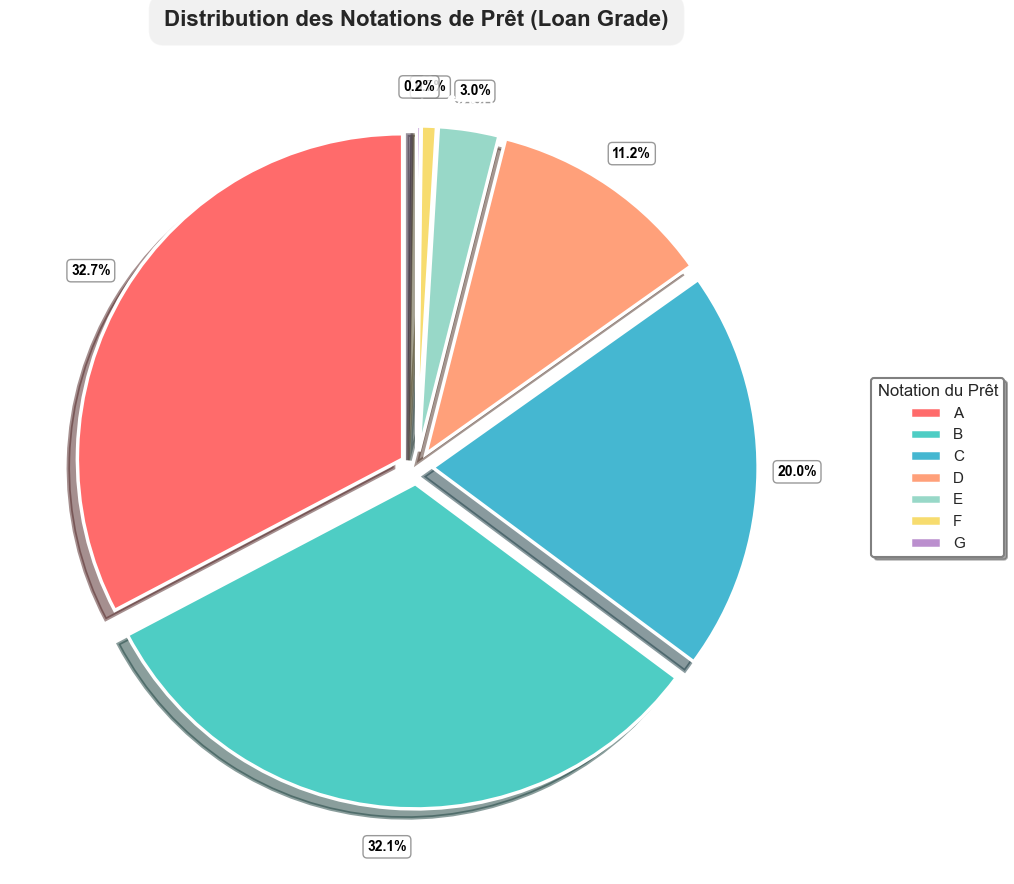

In [ ]:
# Calcul des statistiques par grade 
grade_stats = data.groupby('Loan Grade')['Default Status'].agg(['mean', 'count']).reset_index()
grade_stats.columns = ['Loan Grade', 'Default Rate', 'Count']


# Création de la figure avec taille augmentée
fig, ax = plt.subplots(figsize=(12, 9))

# Palette de couleurs 
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE']
colors = colors[:len(grade_stats)]

# Écartement des parts 
explode = [0.05] * len(grade_stats)

# Tracé du camembert amélioré
wedges, texts, autotexts = ax.pie(
    grade_stats['Count'],
    labels=labels_interieurs,          # À l'intérieur des parts
    autopct='%1.1f%%',                 # Pourcentages générés automatiquement
    startangle=90,
    pctdistance=1.12,                  # Distance des pourcentages
    colors=colors,
    explode=explode,                   # Écarte légèrement les parts
    textprops={'fontsize': 12, 'weight': 'bold', 'color': 'white'},  # labels intérieurs blancs
    wedgeprops={
        'edgecolor': 'white', 
        'linewidth': 2.5,               # bordure plus épaisse
        'antialiased': True
    },
    shadow=True                         # Ajoute une ombre pour l'effet 3D
)

# Personnalisation des pourcentages 
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')
    autotext.set_bbox(dict(
        boxstyle='round,pad=0.3', 
        facecolor='white', 
        edgecolor='gray',
        linewidth=1,
        alpha=0.8
    ))

# Labels intérieurs améliorés
for text in texts:
    text.set_fontsize(13)
    text.set_weight('bold')

# Titre amélioré
ax.set_title(
    'Distribution des Notations de Prêt (Loan Grade)', 
    fontsize=16, 
    fontweight='bold', 
    pad=25,
    bbox=dict(boxstyle='round,pad=0.7', facecolor='lightgray', alpha=0.3)
)

# Légende des couleurs 
legend = ax.legend(
    wedges,
    grade_stats['Loan Grade'],
    title="Notation du Prêt",
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),        # position à droite, légèrement décalée
    fontsize=11,
    title_fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True
)

# Amélioration du style de la légende
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('gray')
legend.get_frame().set_linewidth(1.5)

plt.tight_layout()
plt.show()


### Interprétation

**Analyse de la répartition:**
- La majorité des emprunteurs reçoivent une notation entre A et C (environ 75 %), indiquant que la plupart des demandes de prêt proviennent de profils considérés comme moins risqués.
- Les grades D, E, F et G représentent une proportion plus faible, correspondant aux profils plus risqués.

**Effectivité de la notation:**
- La notation du prêt **reflète efficacement le risque de défaut**: on observe une tendance croissante du taux de défaut avec la dégradation de la notation.
- Les grades supérieurs (meilleure notation = moins de risque) ont les taux de défaut les plus bas.
- Les grades inférieurs (pire notation = plus de risque) ont les taux de défaut les plus élevés.
- Cette progression monotone confirme que le système de notation discrimine bien les emprunteurs en fonction de leur risque de défaut.

# II. Statistique descriptives bivariées

In [ ]:
from statistique_descriptive import bivarié_cat_num
from statistique_descriptive import bivarié_cat_cat
from scipy import stats

### Objectif n°1: Comment la notation des prêts reflète-t-elle efficacement le risque de défaut de paiement de l'emprunteur?

In [ ]:
def default_summary(data, group_col):
    return data.groupby(group_col).agg(
        # Nombre total d'emprunteurs dans chaque groupe (taille de l'échantillon — critique pour la fiabilité)
        total=('Default Status', 'count'),

        # Nombre d'emprunteurs ayant fait défaut (somme des 1 dans la cible binaire)
        defaults=('Default Status', 'sum'),

        # Taux de défaut = moyenne de la cible binaire = proportion de défauts dans le groupe
        default_rate=('Default Status', 'mean'),

        # Borne inférieure de l'intervalle de confiance à 95% pour le taux de défaut.
        # Utilise un intervalle de Wald (approximation normale) via statsmodels.proportion_confint.
        # Des intervalles plus larges signalent des estimations moins fiables (généralement pour les petits groupes).
        ci_lower=('Default Status', lambda x: proportion_confint(x.sum(), len(x), alpha=0.05)[0]),

        # Borne supérieure de l'intervalle de confiance à 95% pour le taux de défaut.
        ci_upper=('Default Status', lambda x: proportion_confint(x.sum(), len(x), alpha=0.05)[1])
    ).reset_index()  # Aplatit l'index du groupby en une colonne ordinaire pour un affichage facile

In [ ]:
#résumé par grade de prêt
pd.set_option('display.float_format', '{:,.2f}'.format)
default_summary(data, 'Loan Grade')

,Loan Grade,total,defaults,default_rate,ci_lower,ci_upper
0,A,10274,982,0.10,0.09,0.10
1,B,10088,1611,0.16,0.15,0.17
2,C,6283,1274,0.20,0.19,0.21
3,D,3529,2075,0.59,0.57,0.60
4,E,943,605,0.64,0.61,0.67
5,F,234,164,0.70,0.64,0.76
6,G,64,63,0.98,0.95,1.00


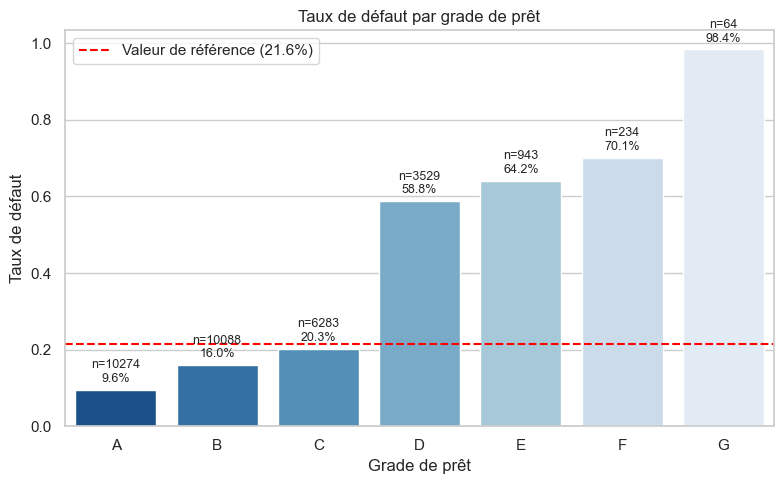

In [ ]:
# Calcule le taux de défaut par grade de prêt
grade_stats = data.groupby('Loan Grade')['Default Status'].agg(['mean', 'count']).reset_index()

# Renomme pour plus de clarté
grade_stats.columns = ['Loan Grade', 'Default Rate', 'Count']

# Taux de base global
baseline = data['Default Status'].mean()

plt.figure(figsize=(8,5))

# Diagramme en barres avec une palette de couleurs modifiée
# Exemples : 'Blues_r', 'Reds_r', 'coolwarm', 'viridis', 'Set2', 'muted', 'pastel'
sns.barplot(
    data=grade_stats,
    x='Loan Grade',
    y='Default Rate',
    palette='Blues_r'      # ← Couleurs modifiées : dégradé de bleu (plus foncé pour les grades élevés)
)

# Ajoute la ligne du taux de base
plt.axhline(baseline, linestyle='--', color='red', label=f'Valeur de référence ({baseline:.1%})')

# Ajoute les annotations (taux + taille de l'échantillon)
for i, row in grade_stats.iterrows():
    plt.text(i, row['Default Rate'] + 0.02,
             f"n={int(row['Count'])}\n{row['Default Rate']:.1%}",
             ha='center', fontsize=9)

plt.title('Taux de défaut par grade de prêt', fontsize=12)  # Titre en français
plt.ylabel('Taux de défaut')
plt.xlabel('Grade de prêt')
plt.legend()

plt.tight_layout()
plt.show()

### interprétation:
1. Observation des tendances
- Le graphique montre une séparation très nette entre les grades A–C (faible risque) et D–G (risque élevé) :
- Grades A, B, C : taux de défaut compris entre environ 12 % et 20 %.
- Grades D, E, F : taux de défaut beaucoup plus élevés, de 58 % à 72 %.
- Le taux de défaut de référence global est de 21,6 %.
- Cette rupture brutale entre C et D indique que le système de notation ne suit pas une échelle linéaire, mais intègre probablement un seuil de risque strict (par exemple, un score minimum imposé par les politiques de prêt).

2. Déséquilibre des effectifs
- La majorité des prêts (n=10 274 pour A ) se concentre sur les grades A–C.
- Les grades à haut risque (D–F) ne représentent qu’un faible nombre d’observations (par exemple n=943 pour E, n=234 pour F, etc.).
- Ce déséquilibre reflète une stratégie de prêt réaliste : les institutions évitent d’accorder massivement des prêts aux profils les plus risqués.

3. Limites méthodologiques
- Les petits effectifs dans les grades D–F rendent les estimations de taux de défaut moins fiables (intervalles de confiance larges). Une interprétation prudente s’impose.
- La valeur de référence globale (21,6 %) est tirée vers le bas par la surreprésentation des grades A–C.

4. Conclusion stratégique
 Le grade de prêt est un indicateur puissant et synthétique du risque de défaut. Il agrège efficacement des informations financières et comportementales des emprunteurs. Pour une gestion du risque optimale :
- Renforcer la segmentation : traiter les grades A–C et D–G comme deux populations distinctes dans les modèles de scoring.
- Collecter plus de données sur les grades D–G pour affiner les estimations.
- Envisager des seuils d’acceptation plus stricts si le taux de défaut observé (>58 %) est jugé trop élevé.

## Correlation des variables numériques avec l'échellon du pret

In [ ]:
grade_numeric = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
data['grade_numeric'] = data['Loan Grade'].map(grade_numeric)
features = {
    'Annual Income': 'Income',
    'Loan % of Income': 'LTI',
    'Employment Length (Years)': 'Employment Length',
    'Credit History Length (Years)': 'Credit History'
}

print(f"{'Variable':<25} {'Correlation avec Loan Grade':<25} {'R²':<10}")
print("-" * 60)

for col, label in features.items():
    r, p = stats.pearsonr(data['grade_numeric'], data[col])
    print(f"{label:<25} {r:<25.4f} {r**2:<10.4f}")

prev_numeric = (data['Previous Default'] == 'Yes').astype(int)
r, p = stats.pearsonr(data['grade_numeric'], prev_numeric)
print(f"{'Previous Default':<25} {r:<25.4f} {r**2:<10.4f}")

Variable                  Correlation avec Loan Grade R²        
------------------------------------------------------------
Income                    -0.0066                   0.0000    
LTI                       0.1241                    0.0154    
Employment Length         -0.0487                   0.0024    
Credit History            0.0133                    0.0002    
Previous Default          0.5359                    0.2872    


### Analyse de la raison des prets

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27024\2400715334.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



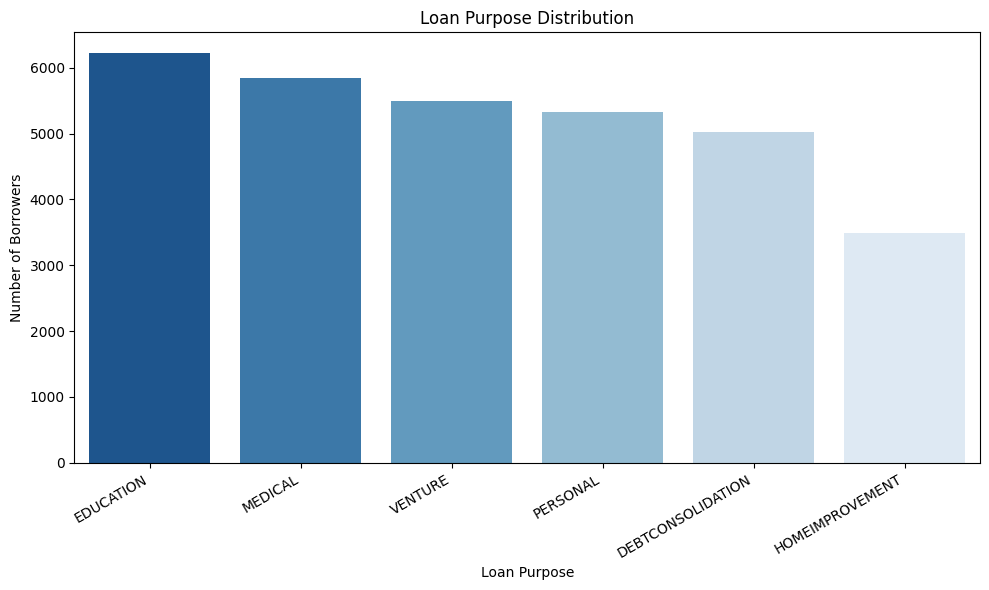

In [ ]:

plt.figure(figsize=(10,6))

order = data['Loan Purpose'].value_counts().index

sns.countplot(
    data=data,
    x='Loan Purpose',
    order=order,
    palette='Blues_r'
)

plt.title('Loan Purpose Distribution')
plt.xlabel('Loan Purpose')
plt.ylabel('Number of Borrowers')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


On observe que la plus grande proportion des prêts contractés par les individus est destinée au financement de l’éducation.

### Analyse du défaut de paiement en fonction des motifs de souscription des prêts

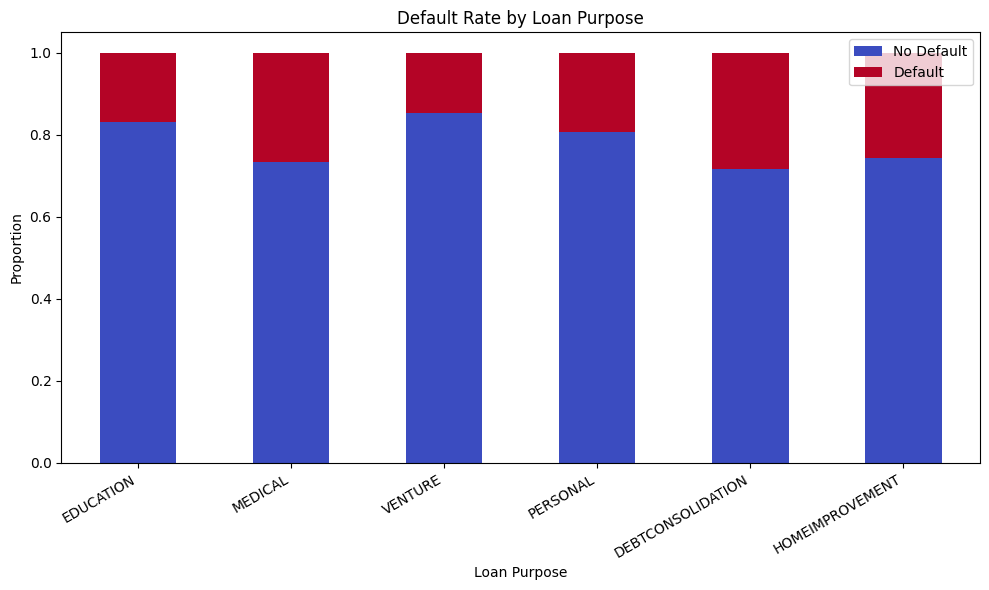

In [ ]:
ct = pd.crosstab(
    data['Loan Purpose'],
    data['Default Status'],
    normalize='index'
)

ct = ct.loc[order]

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='coolwarm'
)

plt.title('Default Rate by Loan Purpose')
plt.ylabel('Proportion')
plt.xlabel('Loan Purpose')
plt.xticks(rotation=30, ha='right')
plt.legend(['No Default', 'Default'])
plt.tight_layout()
plt.show()


### Analyse du taux de selon le statut de logement des emprunteurs.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27024\2163121100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



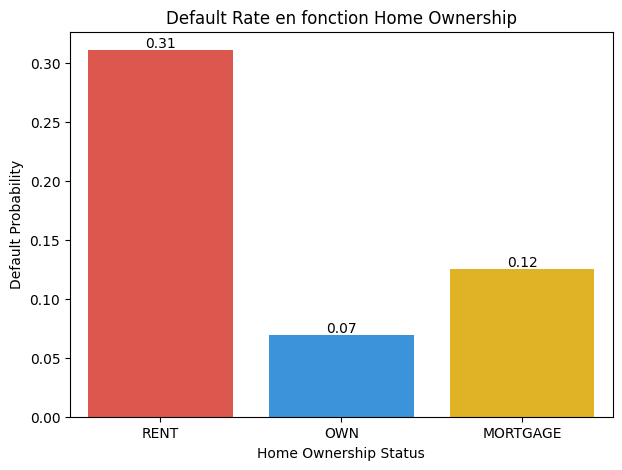

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    x='Home Ownership',
    y='Default Status',
    data=data,
    order=['RENT', 'OWN', 'MORTGAGE'],
    palette=['#F44336', '#2196F3', '#FFC107'],
    errorbar=None
)

# Add labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Default Rate en fonction Home Ownership')
plt.xlabel('Home Ownership Status')
plt.ylabel('Default Probability')
plt.show()


On remarque que la base de donnée est très deséquilibré comme on peut le voir ici environ 18% des prets des individus ne sont pas remboursées

In [ ]:
data['Previous Default'].value_counts(normalize=True) * 100

Previous Default
No     82.221869
Yes    17.778131
Name: proportion, dtype: float64

### Defaut de paiement en fonction des précedents défauts

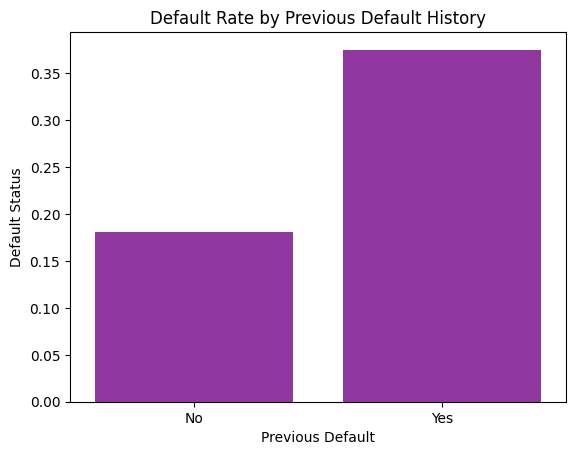

In [ ]:
sns.barplot(x='Previous Default', y='Default Status', data=data, errorbar=None, color='#9C27B0')
plt.title('Default Rate by Previous Default History')
plt.show()

On voit ainsi que la situation de defaut precedent d'un client constitue une variable très importante pour anticiper si un individu paiera sa dette ou non.

### Default rate en fonction de variables importantes

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27024\1240200214.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27024\1240200214.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


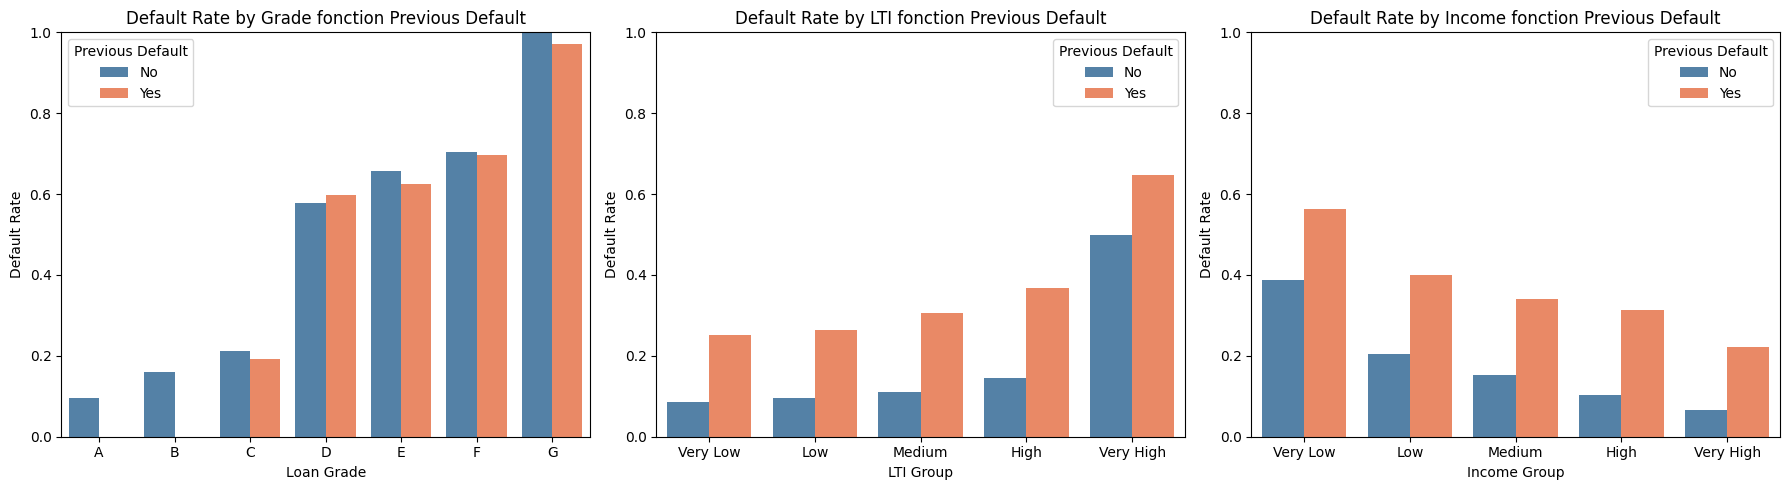

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Create LTI Group before using it
data['LTI Group'] = pd.qcut(data['Loan % of Income'], q=5, labels=["Very Low","Low","Medium","High","Very High"])

# Create Income Group before using it
data['Income Group'] = pd.qcut(data['Annual Income'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# 1. Previous Default x Loan Grade
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grouped1 = (data.groupby(['Loan Grade', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))

sns.barplot(data=grouped1, x='Loan Grade', y='default_rate',
            hue='Previous Default', order=grade_order,
            ax=axes[0], palette=['steelblue', 'coral'])
axes[0].set_title('Default Rate by Grade fonction Previous Default')
axes[0].set_xlabel('Loan Grade')
axes[0].set_ylabel('Default Rate')
axes[0].set_ylim(0, 1)

# 2. Previous Default x LTI Group
grouped2 = (data.groupby(['LTI Group', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))
lti_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
sns.barplot(data=grouped2, x='LTI Group', y='default_rate',
            hue='Previous Default', order=lti_order,
            ax=axes[1], palette=['steelblue', 'coral'])
axes[1].set_title('Default Rate by LTI fonction Previous Default')
axes[1].set_xlabel('LTI Group')
axes[1].set_ylabel('Default Rate')
axes[1].set_ylim(0, 1)

# 3. Previous Default x Income Group
grouped3 = (data.groupby(['Income Group', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))
income_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
sns.barplot(data=grouped3, x='Income Group', y='default_rate',
            hue='Previous Default', order=income_order,
            ax=axes[2], palette=['steelblue', 'coral'])
axes[2].set_title('Default Rate by Income fonction Previous Default')
axes[2].set_xlabel('Income Group')
axes[2].set_ylabel('Default Rate')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Default rate versus Age Group

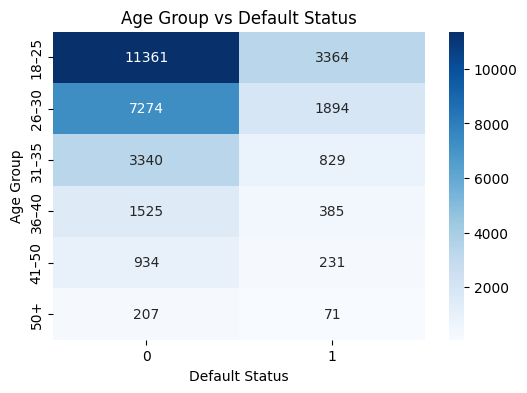

Default Status      0     1
Age Group                  
18–25           11361  3364
26–30            7274  1894
31–35            3340   829
36–40            1525   385
41–50             934   231
50+               207    71


In [ ]:
bivarié_cat_cat(data, "Age Group", "Default Status")

On remarque que les groupes d'age les plus en defaut de paiements sont les plus jeunes agée de 18 à 25 ans.

### Structure de la correlation

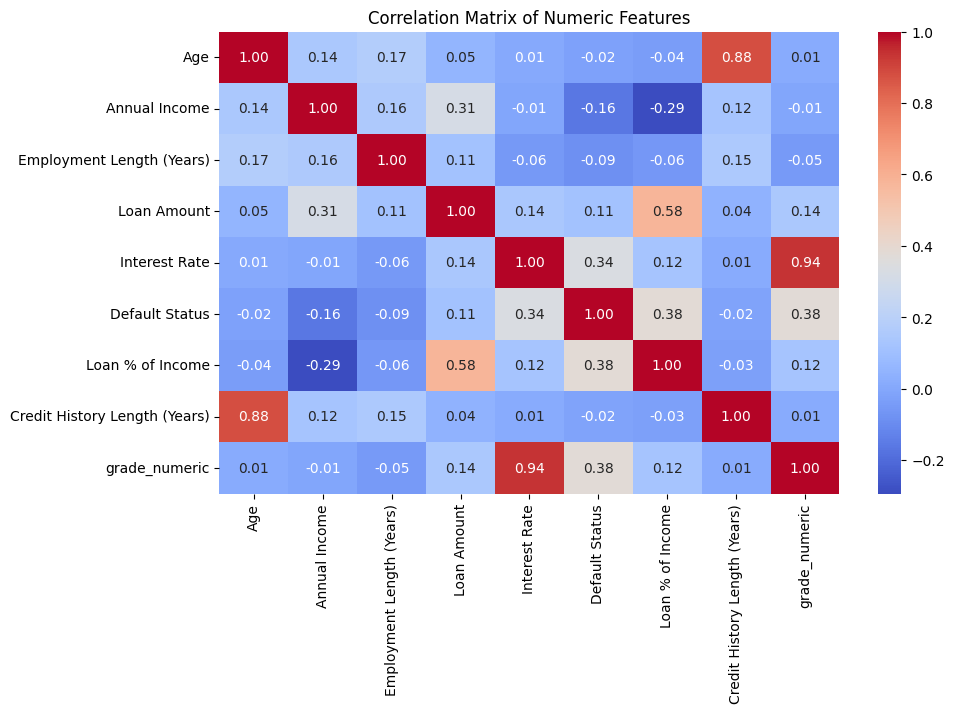

In [ ]:
# This heatmap visualizes the correlation between all numeric features.
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de correlation des variables numériques')
plt.show()

Comme nous l'avons précedemment vu, la nature du credit précedent de la personne influence grandement s'il sera en defaut ou non.

## Creation du modèle

In [13]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=["Default Status"])
y = data["Default Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [14]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Default Status
0    0.784357
1    0.215643
Name: proportion, dtype: float64
Default Status
0    0.784403
1    0.215597
Name: proportion, dtype: float64


### Fonction de scoring

$$
WoE_i = \ln \left( \frac{ \frac{n_i^{(non\_defaut)}}{N^{(non\_defaut)}} }{ \frac{n_i^{(defaut)}}{N^{(defaut)}} } \right)
$$

- WoE > 0  → catégorie "bonne" (plus de non-défauts)
- WoE < 0  → catégorie "risquée" (plus de défauts)
- WoE ≈ 0  → neutre

In [15]:
target = "Default Status"
features = [
    "Home Ownership",
    "Loan Purpose",
    "Loan Grade",
    "LTI Group",
    "Income Group",
    "Age Group",
    "Interest Rate Group",
    "Previous Default",
    "Credit History Length (Years)"
]

In [16]:
def fonction_scoring(X, y, col):
    tab = pd.crosstab(X[col], y)
    
    tab.columns = ['non_def', 'def']
    
    tab['dist_non_def'] = tab['non_def'] / tab['non_def'].sum()
    tab['dist_def'] = tab['def'] / tab['def'].sum()
    
    tab['WoE'] = np.log(tab['dist_non_def'] / tab['dist_def'])
    tab['IV'] = (tab['dist_non_def'] - tab['dist_def']) * tab['WoE']
    
    return tab, tab['IV'].sum()

In [17]:
X_train_woe = pd.DataFrame()
X_test_woe = pd.DataFrame()

In [18]:
woe_maps = {}

for col in features:
    table, _ = fonction_scoring(X_train, y_train, col)
    
    # sauver le mapping WoE
    woe_maps[col] = table['WoE']
    
    # appliquer transformation
    X_train_woe[col] = X_train[col].map(table['WoE'])

In [19]:
for col in features:
    table = fonction_scoring(X_train, y_train, col)[0]
    X_test_woe[col] = X_test[col].map(table['WoE'])

In [20]:
X_train_woe = X_train_woe.fillna(0)
X_test_woe = X_test_woe.fillna(0)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_woe, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Prediction du score

In [22]:
y_proba = model.predict_proba(X_test_woe)[:,1]

### Transformation en score de defaut

In [25]:
score = 300 + (y_proba - y_proba.min()) * 550 / (y_proba.max() - y_proba.min())

In [26]:
score

array([358.63485431, 316.24680012, 430.19104846, ..., 336.48885458,
       315.6932498 , 370.08019966], shape=(9425,))

(array([2440., 1452.,  890.,  580.,  466.,  386.,  301.,  286.,  216.,
         188.,  177.,  154.,  190.,  140.,  145.,   93.,  101.,  121.,
         129.,  124.,  105.,   79.,  109.,  102.,   94.,   69.,   65.,
          76.,   87.,   60.]),
 array([300.        , 318.33333333, 336.66666667, 355.        ,
        373.33333333, 391.66666667, 410.        , 428.33333333,
        446.66666667, 465.        , 483.33333333, 501.66666667,
        520.        , 538.33333333, 556.66666667, 575.        ,
        593.33333333, 611.66666667, 630.        , 648.33333333,
        666.66666667, 685.        , 703.33333333, 721.66666667,
        740.        , 758.33333333, 776.66666667, 795.        ,
        813.33333333, 831.66666667, 850.        ]),
 <BarContainer object of 30 artists>)

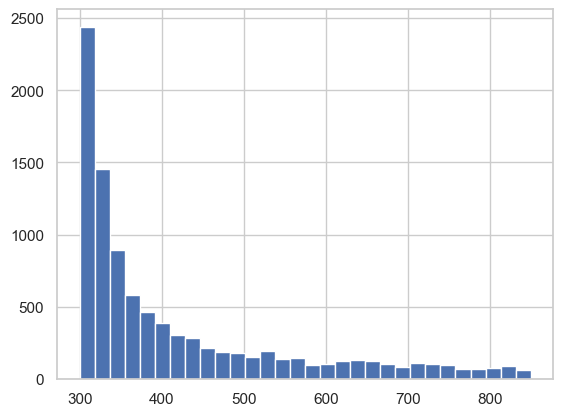

In [27]:
import matplotlib.pyplot as plt

plt.hist(score, bins=30)